In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

In [2]:
df = sns.load_dataset("titanic")

#Display first 5 rows
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [3]:
print("Shape of Dataset:",df.shape)
print("\ncolumn Name:")
print(df.columns)
print("\nDataset Information:")
df.info()

Shape of Dataset: (891, 15)

column Name:
Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='object')

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object

In [4]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64


In [5]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


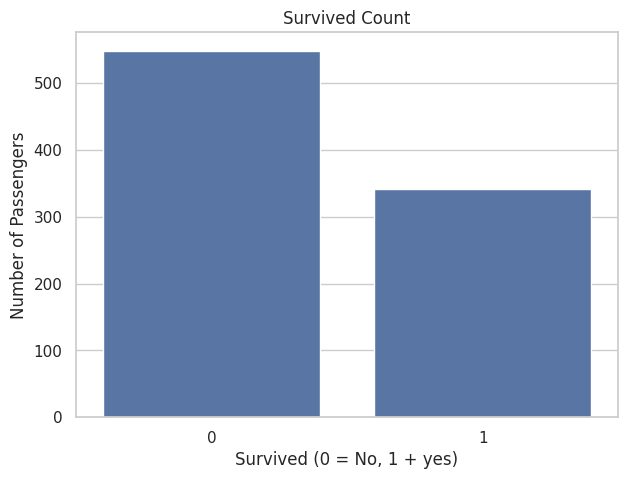

In [6]:
plt.figure(figsize=(7,5))
sns.countplot(data=df,x="survived")
plt.title("Survived Count")
plt.xlabel("Survived (0 = No, 1 + yes)")
plt.ylabel("Number of Passengers")
plt.show()


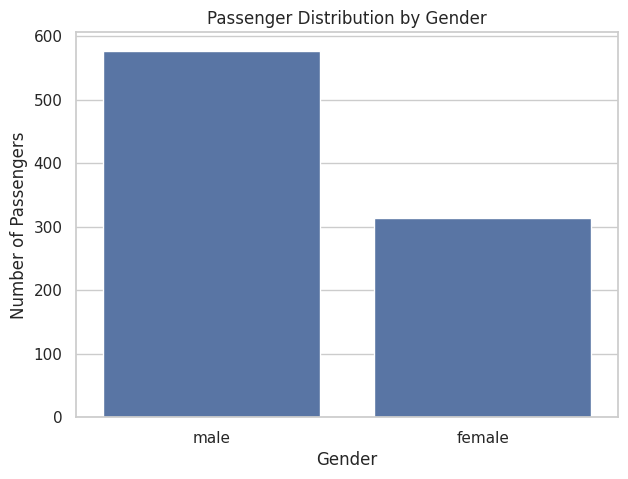

In [7]:
plt.figure(figsize=(7,5))
sns.countplot(data=df,x="sex")
plt.title("Passenger Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Passengers")
plt.show()

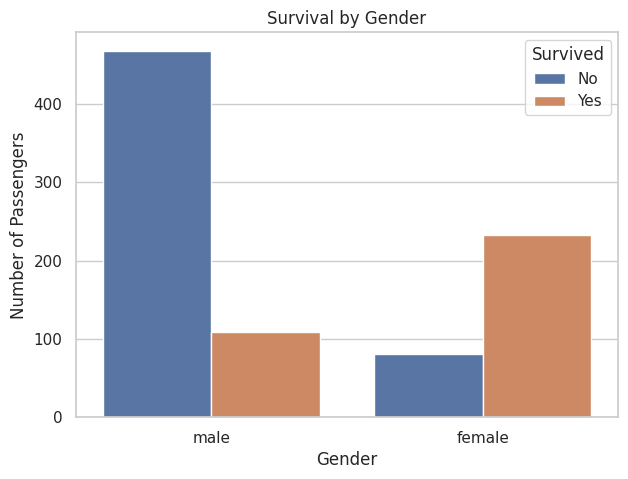

In [8]:
plt.figure(figsize=(7,5))
sns.countplot(data=df,x="sex",hue="survived")
plt.title("Survival by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Passengers")
plt.legend(title="Survived", labels=["No", "Yes"])
plt.show()


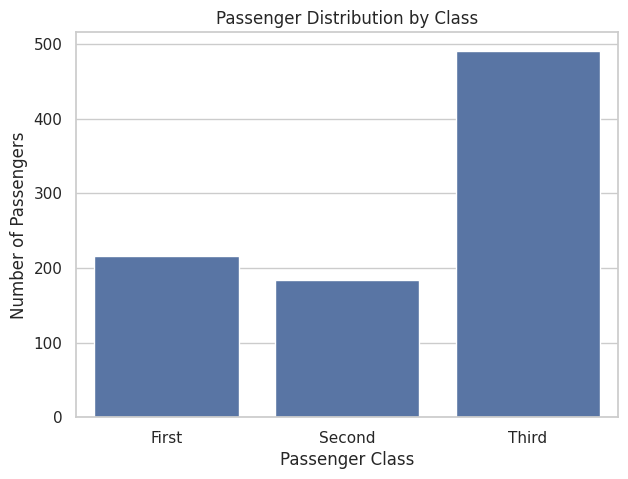

In [9]:
plt.figure(figsize=(7,5))
sns.countplot(data=df,x="class")
plt.title("Passenger Distribution by Class")
plt.xlabel("Passenger Class")
plt.ylabel("Number of Passengers")
plt.show()

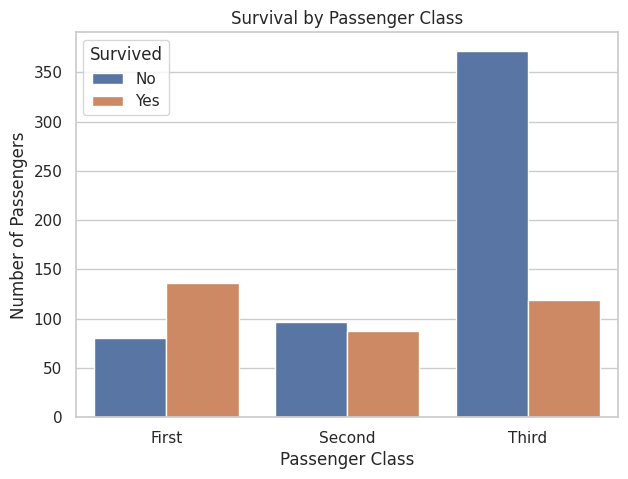

In [10]:
plt.figure(figsize=(7,5))
sns.countplot(data=df,x="class",hue="survived")
plt.title("Survival by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Number of Passengers")
plt.legend(title="Survived", labels=["No", "Yes"])
plt.show()

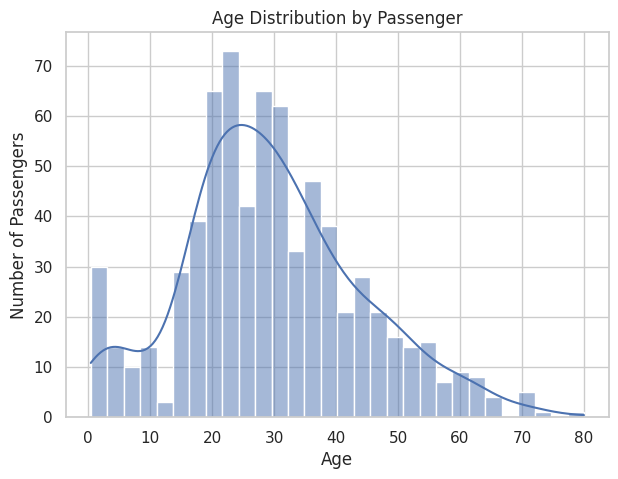

In [12]:
plt.figure(figsize=(7,5))
sns.histplot(data=df,x="age",bins=30,kde=True)
plt.title("Age Distribution by Passenger")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")
plt.show()

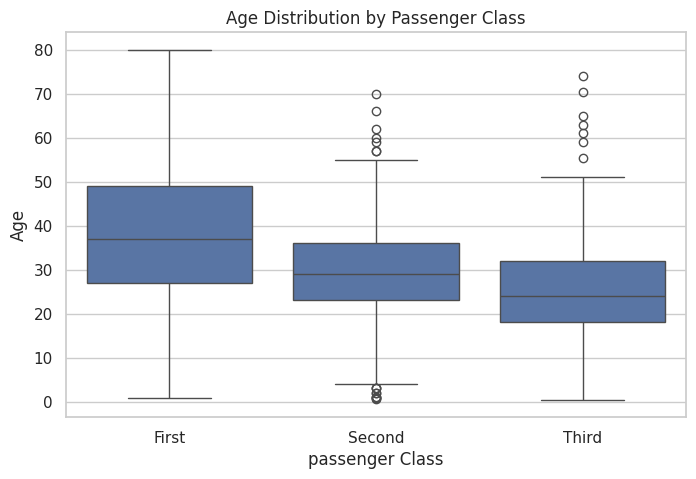

In [13]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df,x="class",y="age")
plt.title("Age Distribution by Passenger Class")
plt.xlabel("passenger Class")
plt.ylabel("Age")
plt.show()

In [14]:
numeric_df=df.select_dtypes(include=np.number)
correlation=numeric_df.corr()
print(correlation)

          survived    pclass       age     sibsp     parch      fare
survived  1.000000 -0.338481 -0.077221 -0.035322  0.081629  0.257307
pclass   -0.338481  1.000000 -0.369226  0.083081  0.018443 -0.549500
age      -0.077221 -0.369226  1.000000 -0.308247 -0.189119  0.096067
sibsp    -0.035322  0.083081 -0.308247  1.000000  0.414838  0.159651
parch     0.081629  0.018443 -0.189119  0.414838  1.000000  0.216225
fare      0.257307 -0.549500  0.096067  0.159651  0.216225  1.000000


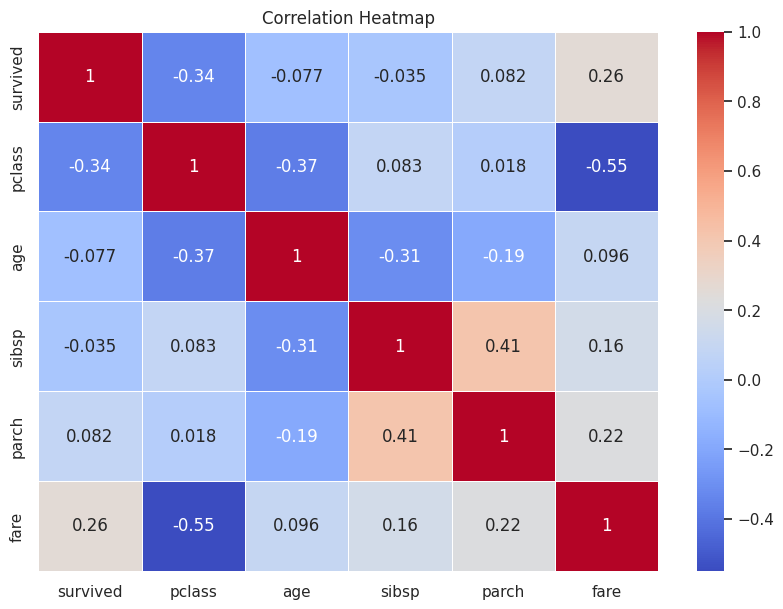

In [15]:
plt.figure(figsize=(10,7))
sns.heatmap(correlation,annot=True,cmap="coolwarm",linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

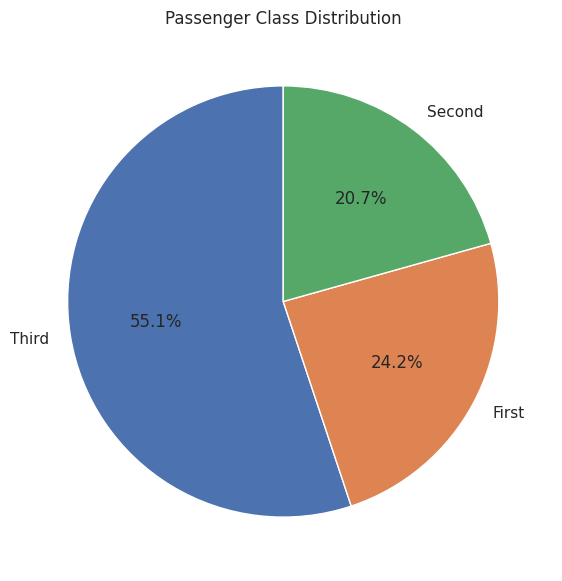

In [17]:
class_count=df["class"].value_counts()
plt.figure(figsize=(7,7))
plt.pie(class_count,labels=class_count.index,autopct="%1.1f%%",startangle=90)
plt.title("Passenger Class Distribution")
plt.show()

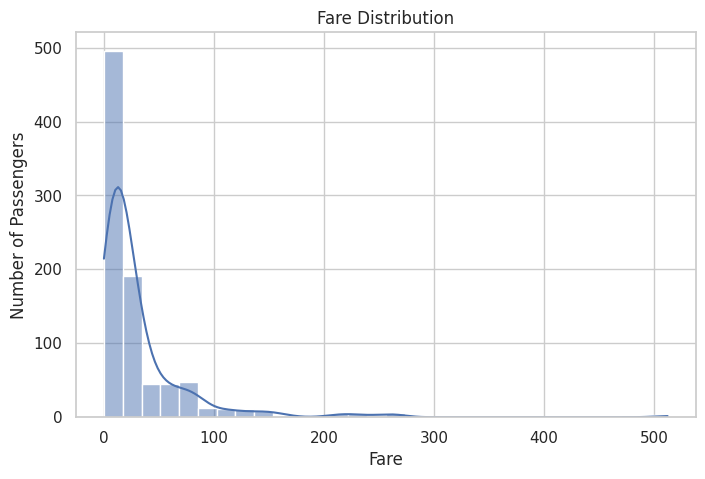

In [20]:
plt.figure(figsize=(8,5))
sns.histplot(data=df,x="fare",bins=30, kde=True)
plt.title("Fare Distribution")
plt.xlabel("Fare")
plt.ylabel("Number of Passengers")
plt.show()

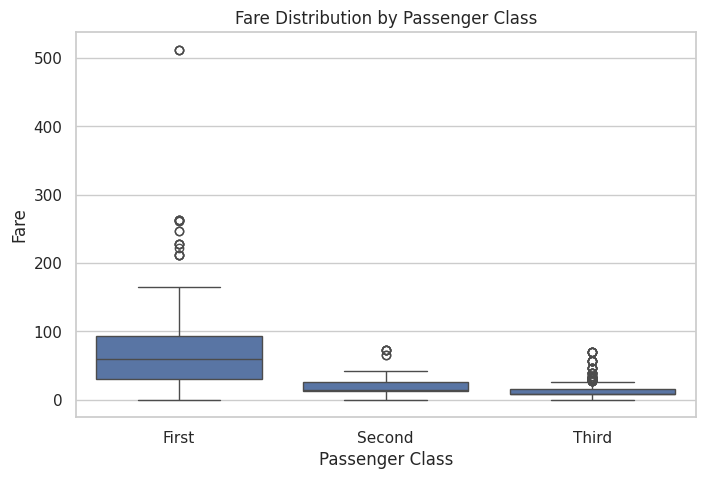

In [21]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df,x="class",y="fare")
plt.title("Fare Distribution by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Fare")
plt.show()


In [23]:
survival_rate = df.groupby("sex")["survived"].mean() * 100
print(survival_rate)

sex
female    74.203822
male      18.890815
Name: survived, dtype: float64


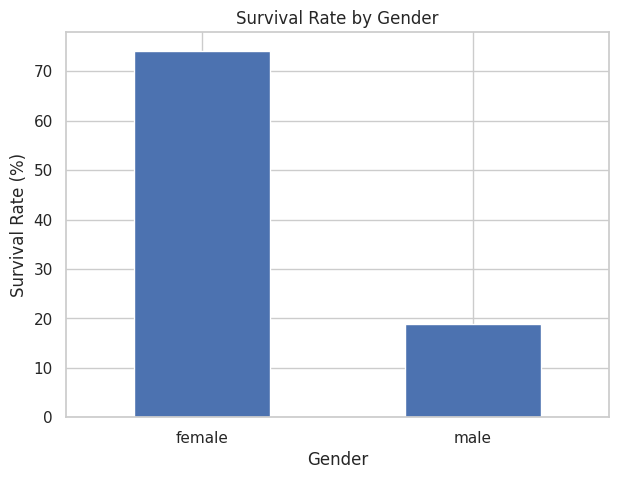

In [25]:
plt.figure(figsize=(7,5))
survival_rate.plot(kind="bar")
plt.title("Survival Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Survival Rate (%)")
plt.xticks(rotation=0)
plt.show()

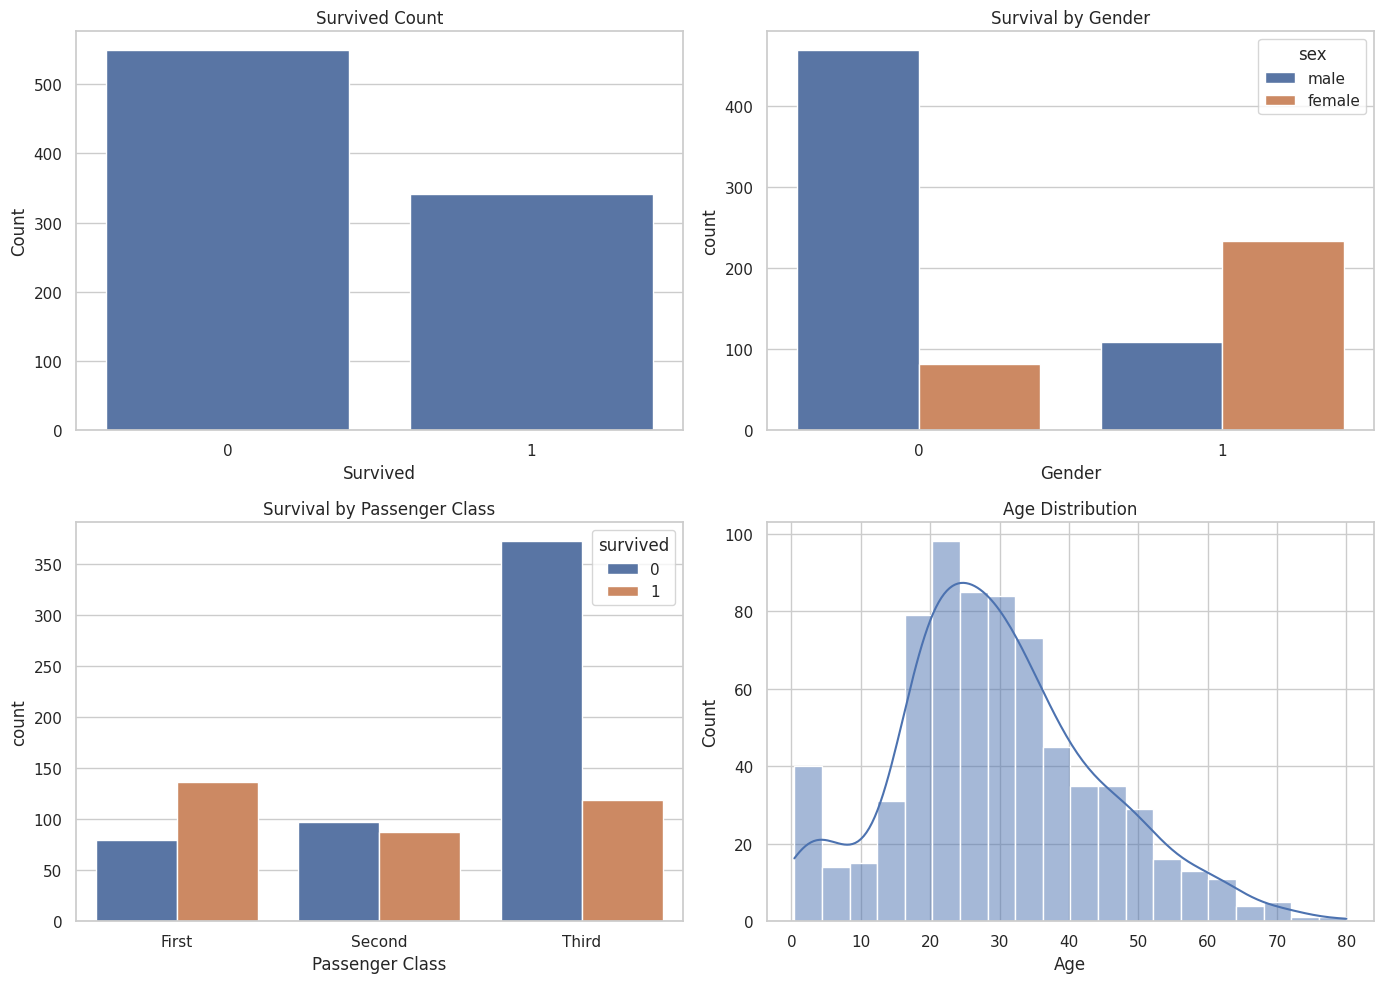

In [26]:
fig,axes = plt.subplots(2,2,figsize=(14,10))
#chart 1
sns.countplot(data=df,x="survived",ax=axes[0,0])
axes[0,0].set_title("Survived Count")
axes[0,0].set_xlabel("Survived")
axes[0,0].set_ylabel("Count")
#chart 2
sns.countplot(data=df,hue="sex",x="survived",ax=axes[0,1])
axes[0,1].set_title("Survival by Gender")
axes[0,1].set_xlabel("Gender")
#chart 3
sns.countplot(data=df,x="class",hue="survived",ax=axes[1,0])
axes[1,0].set_title("Survival by Passenger Class")
axes[1,0].set_xlabel("Passenger Class")
#chart 4
sns.histplot(data=df,x="age",kde="True",ax=axes[1,1])
axes[1,1].set_title("Age Distribution")
axes[1,1].set_xlabel("Age")
plt.tight_layout()
plt.show()

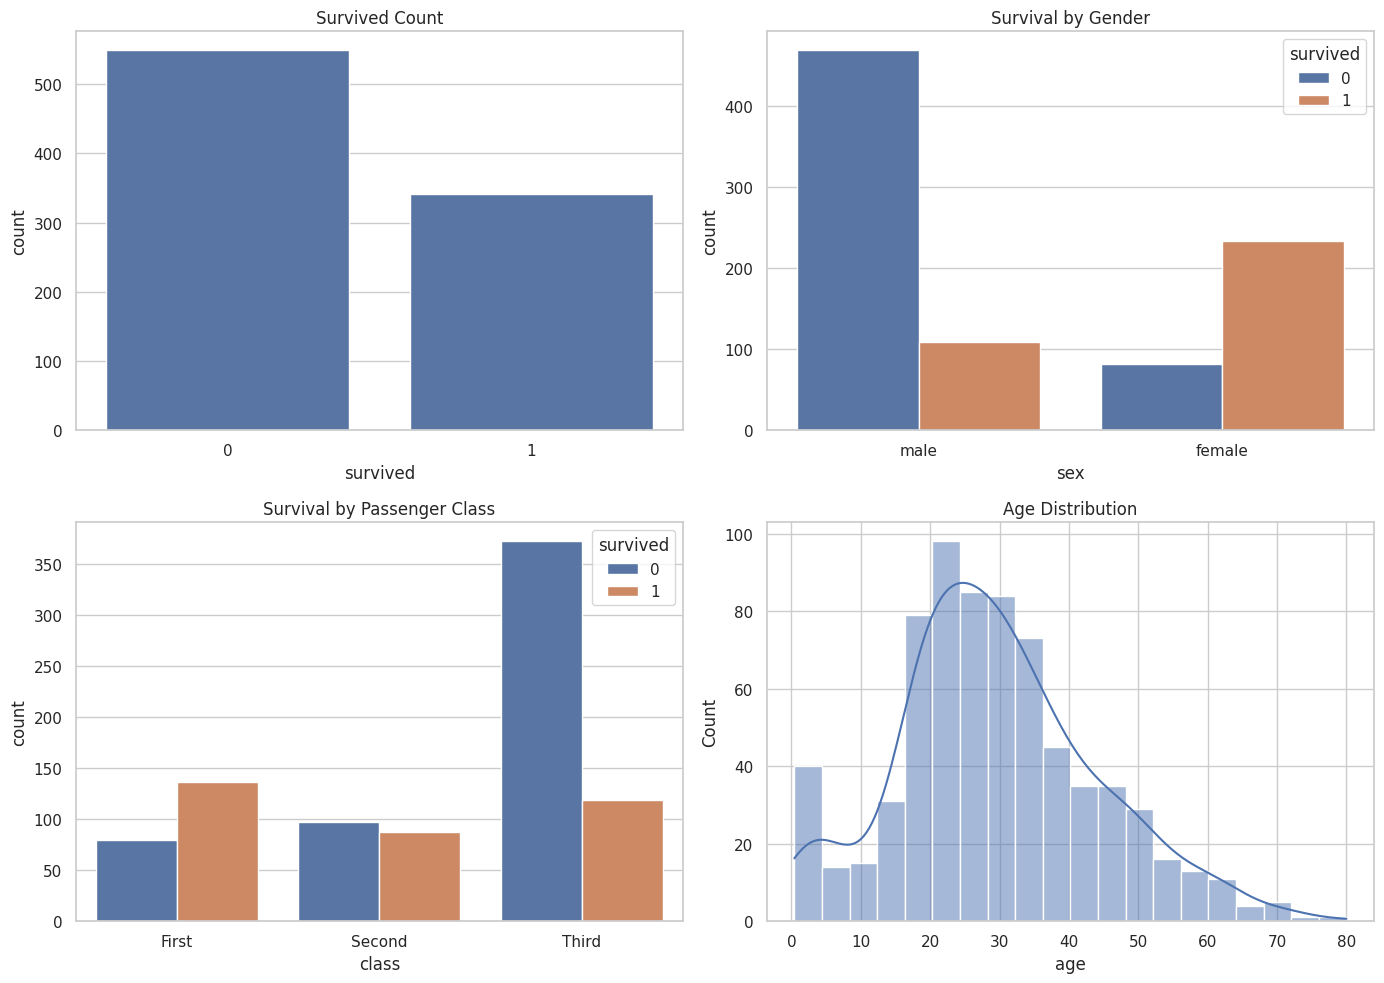

In [27]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
sns.countplot(data=df, x="survived", ax=axes[0, 0])
axes[0, 0].set_title("Survived Count")

sns.countplot(data=df, x="sex", hue="survived", ax=axes[0, 1])
axes[0, 1].set_title("Survival by Gender")

sns.countplot(data=df, x="class", hue="survived", ax=axes[1, 0])
axes[1, 0].set_title("Survival by Passenger Class")

sns.histplot(data=df, x="age", kde=True, ax=axes[1, 1])
axes[1, 1].set_title("Age Distribution")

plt.tight_layout()

plt.savefig("Task3_Data_Visualization.png", dpi=300)

plt.show()



DATA VISUALIZATION FINDINGS

1.The dataset contains information about titanic passengers.
2. The visualization show the distribution of passengers by gender and class.
3. Survival rates can be compared across different gebder and passenger classes.
4. Age distribution shows the range of passemger ages.
5. Fare distribution shows differences in ticket prices.
6. the correlation heatmap helps identify ralationship between numerical variables.
7. Different charts make it easier to understand patterns and trends in the dataset